<a href="https://colab.research.google.com/github/tasinfrancesco/Practical_ML_PSL/blob/main/Trentino_personale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
l = pd.read_csv("listings.csv")
ll = pd.read_csv("listings_large.csv")
print(l.head(), ll.head())

       id                                         name  host_id  host_name  \
0   37736          Charming cozy apartment North Italy   162348    Daniele   
1   56292  Central apartment located on the ski slopes   266605    Stefano   
2  249351          B&B Casa dei Ricci in the Dolomites  1306234  Maddalena   
3  299464       Residence Segattini Studio 2-3 Persone  1543124  Cristiano   
4  367596            Apartment in Val Rendena, Pinzolo  1854440     Franca   

   neighbourhood_group neighbourhood  latitude  longitude        room_type  \
0                  NaN      Trentino  46.43561   11.10380  Entire home/apt   
1                  NaN      Trentino  46.23199   10.82732  Entire home/apt   
2                  NaN      Trentino  46.36155   10.91591     Private room   
3                  NaN      Trentino  45.90883   10.84660  Entire home/apt   
4                  NaN      Trentino  46.15799   10.76669  Entire home/apt   

   price  minimum_nights  number_of_reviews last_review  revie

host_listings_count
1.0       4.724423
2.0       4.718513
3.0       4.707810
4.0       4.689257
5.0       4.710157
            ...   
1113.0    5.000000
1247.0    4.615000
1405.0    4.351765
1440.0    4.330000
1874.0         NaN
Name: review_scores_value, Length: 128, dtype: float64


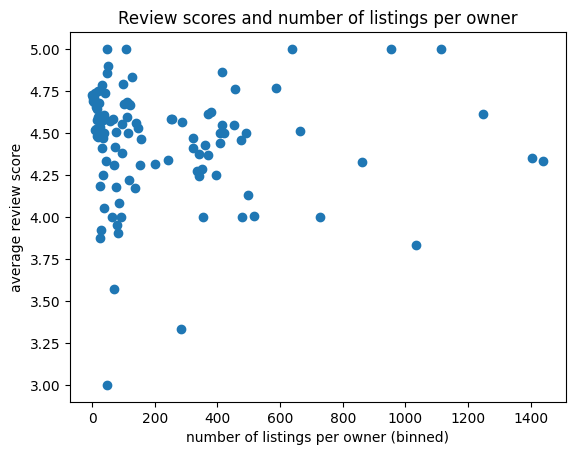

In [65]:
import matplotlib.pyplot as plt
import numpy as np

ll['listings_bin'] = pd.cut(ll['host_listings_count'], bins=25)
x = ll.groupby("host_listings_count")["review_scores_value"].mean()
print(x)
f1 = plt.figure()
plt.scatter(x.index, x.values)
plt.xlabel("number of listings per owner (binned)")
plt.ylabel("average review score")
plt.title("Review scores and number of listings per owner")
plt.show()
f1.savefig("reviews and number of listings")

TN_dist
0.000236       5.00
0.000685       4.82
0.000740       5.00
0.000949       5.00
0.001117        NaN
               ... 
4627.478301    5.00
4628.104775    4.77
4630.664910     NaN
4741.934228     NaN
4810.116801    4.67
Name: review_scores_location, Length: 8578, dtype: float64


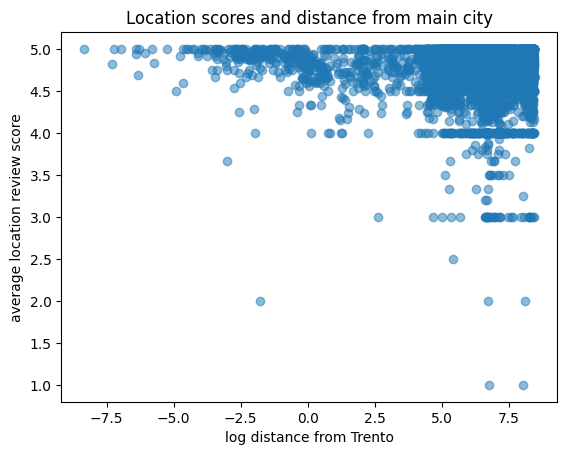

[[ 1.         -0.01179081]
 [-0.01179081  1.        ]]


In [64]:
lat_TN=46.0679
lon_TN=11.1211
def distance_trento(lon, lat):
  d = ((lon-lon_TN)*77)**2 + (111*(lat-lat_TN))**2
  return d

dists = [distance_trento(ll['longitude'][i],ll['latitude'][i]) for i in range(l.shape[0])]
ll["TN_dist"] = dists
x = ll.groupby("TN_dist")['review_scores_location'].mean()
print(x)
f3 = plt.figure()
plt.scatter(np.log(x.index), x.values, alpha = .5)
plt.xlabel("log distance from Trento")
plt.ylabel("average location review score")
plt.title("Location scores and distance from main city")
plt.show()
ll_clean=ll[['TN_dist', 'review_scores_location']].dropna()
print(np.corrcoef(ll_clean['TN_dist'], ll_clean['review_scores_location']))
f3.savefig("Locations and distance")